Cell 1 — install:

In [ ]:
!pip uninstall -y pillow -q
!pip cache purge -q
!pip install --no-cache-dir --force-reinstall "pillow==11.0.0" -q
!pip install -U transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 54.9 MB/s eta 0:00:00


In [ ]:
from PIL import Image
print("Pillow OK")

Pillow OK


Cell 2 — torchaudio fix + load depth model:

In [ ]:
import sys
import types
import importlib.machinery

fake_torchaudio = types.ModuleType("torchaudio")
fake_torchaudio.__spec__ = importlib.machinery.ModuleSpec("torchaudio", loader=None)
sys.modules["torchaudio"] = fake_torchaudio

import torch
from transformers import pipeline

depth_estimator = pipeline(
    task="depth-estimation",
    model="Intel/dpt-hybrid-midas",
    device=0 if torch.cuda.is_available() else -1
)
print("Depth model loaded")

config.json:   0%|          | 0.00/9.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  490MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  490MB            

model.safetensors: downloading bytes:           |  0.00B            

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

Depth model loaded


Cell 3 — upload the same room1.jpg and run depth estimation:

Saving room1.jpg to room1.jpg


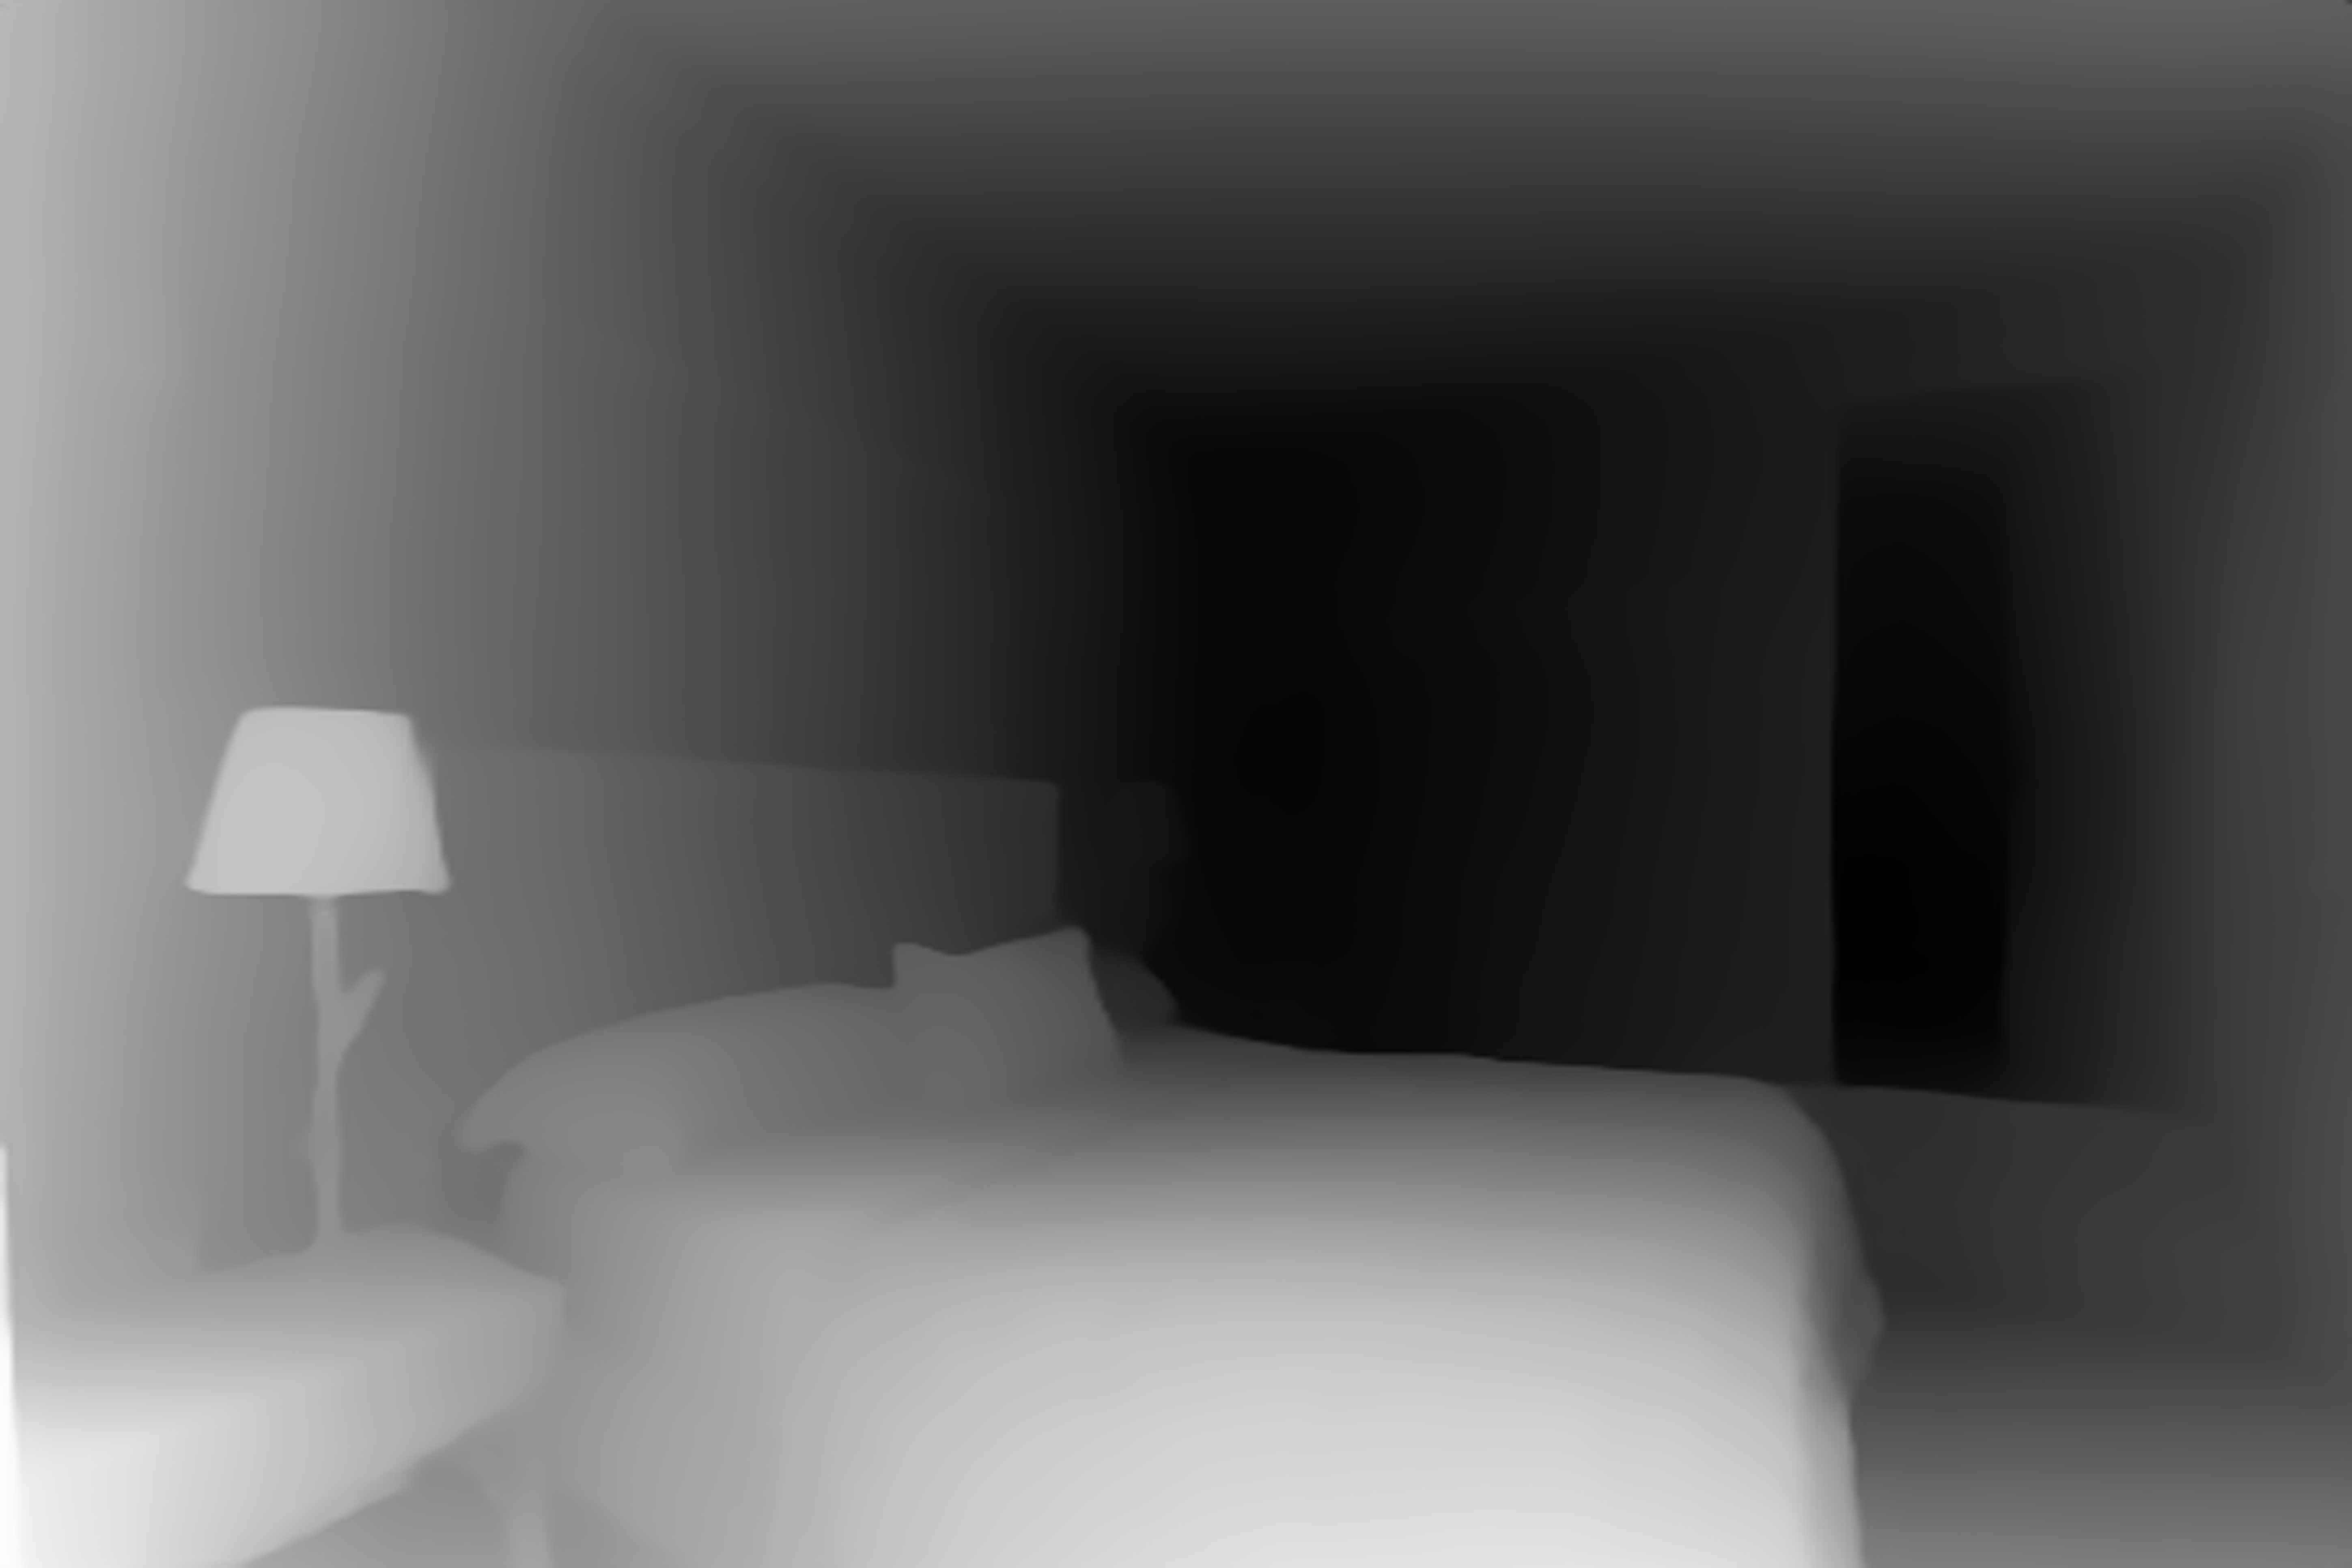

In [ ]:
from google.colab import files
import io
from PIL import Image

uploaded = files.upload()
filename = list(uploaded.keys())[0]
image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

result = depth_estimator(image)
depth_map = result["depth"]

depth_map

Cell 4 — save it for later use in Step 5:

In [ ]:
depth_map.save("room1_depth.png")
print("Depth map saved")

Depth map saved


In [ ]:
def estimate_depth(image: Image.Image) -> Image.Image:
    result = depth_estimator(image)
    return result["depth"]